# AIMLCZG546 - Software Engineering for Machine Learning
## Assignment II - AI Resume Screening System
### Group 179

This notebook demonstrates Assignment I continuity, an explicit research
prototype, production refactoring, measured quality, API behavior, and automated
verification.

## Group details

| BITS ID | Name | Contribution | Percentage |
|---|---|---|---:|
| 2025AB05113 | Prashant | ML implementation and API, Architecture and code quality |  |
| 2025AA05032 | Prathap Wagle | ML implementation and API, Architecture and code quality |  |
| 2024AC05999 | Prasanna R T | Test design, execution and review |  |
| 2024AC05914 | Pranav Mehrotra | QA evidence and final review |  |

## 1. Continuity from Assignment I

Assignment II preserves the same resume-screening domain, labelled role data,
TF-IDF/logistic-regression pipeline, explanation rules, upload workflow, human
oversight, and audit history. The monolithic Assignment I implementation is
separated into `ml/`, `services/`, `app/`, tests, and a Streamlit consumer.

## 2. Research code: inline preprocessing prototype

This deliberately compact cell represents notebook-oriented research code. It
has no reusable module boundary, structured logging, type/error contract, size
limit, or test isolation.

In [1]:
import re

def prototype_clean_text(text):
    return re.sub(r"\\s+", " ", re.sub(r"[^a-z0-9+#. ]", " ", text.lower())).strip()

prototype_clean_text("  Python   TESTING!! ")

'python   testing'

### Production version of the same component

The production `clean_text` function is importable, deterministic, logged, typed,
length-limited, and rejects empty, non-string, and semantically empty input. Its
behavior is covered by unit and API-integration tests.

In [2]:
from ml.preprocessing import clean_text

clean_text("  Python   TESTING!! ")

'python testing'

## 3. Research exploration and baseline comparison

The research path first checks class balance and text-length distribution, then
compares two lightweight text-classification baselines on the same fixed,
stratified holdout. This makes the production choice traceable rather than
presenting a single unexplained model.

In [3]:
from sklearn.model_selection import train_test_split

from ml.data import build_training_data

frame = build_training_data()
eda = {
    "class_counts": frame["job_role"].value_counts().sort_index().to_dict(),
    "text_length_summary": frame["resume_text"].str.len().describe().round(2).to_dict(),
}
eda

{'class_counts': {'Backend Developer': 4,
  'Data Engineer': 4,
  'Data Scientist': 4,
  'DevOps Engineer': 4,
  'Frontend Developer': 4,
  'QA Engineer': 4},
 'text_length_summary': {'count': 24.0,
  'mean': 76.96,
  'std': 8.3,
  'min': 65.0,
  '25%': 71.0,
  '50%': 75.0,
  '75%': 81.0,
  'max': 95.0}}

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

train_text, valid_text, train_role, valid_role = train_test_split(
    frame["resume_text"], frame["job_role"], test_size=0.5, random_state=42,
    stratify=frame["job_role"],
)
baseline_results = {}
for name, classifier in {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
}.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("model", classifier),
    ])
    pipeline.fit(train_text, train_role)
    predicted = pipeline.predict(valid_text)
    baseline_results[name] = {
        "accuracy": accuracy_score(valid_role, predicted),
        "weighted_f1": f1_score(valid_role, predicted, average="weighted"),
    }
baseline_results

{'MultinomialNB': {'accuracy': 1.0, 'weighted_f1': 1.0},
 'LogisticRegression': {'accuracy': 1.0, 'weighted_f1': 1.0}}

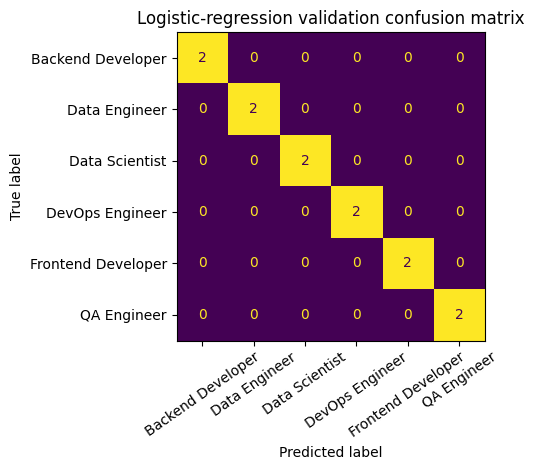

,precision,recall,f1-score,support
Backend Developer,1.0,1.0,1.0,2.0
Data Engineer,1.0,1.0,1.0,2.0
Data Scientist,1.0,1.0,1.0,2.0
DevOps Engineer,1.0,1.0,1.0,2.0
Frontend Developer,1.0,1.0,1.0,2.0
QA Engineer,1.0,1.0,1.0,2.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,12.0
weighted avg,1.0,1.0,1.0,12.0


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# The final loop iteration is the selected logistic-regression baseline.
classification_table = pd.DataFrame(
    classification_report(valid_role, predicted, output_dict=True)
).transpose().round(3)
ConfusionMatrixDisplay.from_predictions(
    valid_role,
    predicted,
    xticks_rotation=35,
    colorbar=False,
)
plt.title("Logistic-regression validation confusion matrix")
plt.tight_layout()
plt.show()
classification_table

Logistic regression is retained for production because it provides
stable multiclass probabilities, deterministic training, and interpretable
linear behavior. The small synthetic dataset is workflow evidence, not a claim
of real-world generalization.

## 4. Measured model and data quality

In [6]:
from pathlib import Path

from logging_config import configure_logging
from ml.data import build_training_data, validate_training_data
from ml.trainer import MIN_ACCURACY, MIN_WEIGHTED_F1, train_model

configure_logging()
frame = build_training_data()
data_quality = validate_training_data(frame)
metrics = train_model(
    frame,
    Path("models/resume_classifier.joblib"),
    Path("report/metrics_snapshot.json"),
)
data_quality, metrics, {"accuracy_gate": MIN_ACCURACY, "f1_gate": MIN_WEIGHTED_F1}

2026-08-09 11:44:28,008 | INFO | ml.data | Created demonstration dataset with 24 rows


2026-08-09 11:44:28,016 | INFO | ml.data | Data quality validation completed: DataQualityReport(row_count=24, missing_values=0, duplicate_rows=0, schema_valid=True, class_count=6)


2026-08-09 11:44:28,020 | INFO | ml.data | Data quality validation completed: DataQualityReport(row_count=24, missing_values=0, duplicate_rows=0, schema_valid=True, class_count=6)


2026-08-09 11:44:28,022 | INFO | ml.preprocessing | Preprocessed resume: 94 -> 94 characters


2026-08-09 11:44:28,022 | INFO | ml.preprocessing | Preprocessed resume: 95 -> 95 characters


...

2026-08-09 11:44:28,031 | INFO | ml.preprocessing | Preprocessed resume: 72 -> 72 characters


2026-08-09 11:44:28,033 | INFO | ml.trainer | Starting model training with 12 training rows


2026-08-09 11:44:28,065 | INFO | ml.trainer | Saved metrics snapshot to report\metrics_snapshot.json


2026-08-09 11:44:28,067 | INFO | ml.trainer | Saved trained model to models\resume_classifier.joblib; metrics={'accuracy': 1.0, 'weighted_f1': 1.0, 'multiclass_brier': 0.7248547475050567, 'top_3_accuracy': 1.0, 'validation_rows': 12, 'schema_valid': True, 'missing_values': 0, 'duplicate_rows': 0, 'data_quality': {'schema_valid': True, 'missing_value_rate': 0.0, 'duplicate_rows': 0, 'class_count': 6, 'minority_class_fraction': 0.16666666666666666, 'text_length_mean': 76.95833333333333, 'text_length_std': 8.121366709010388}}


(DataQualityReport(row_count=24, missing_values=0, duplicate_rows=0, schema_valid=True, class_count=6),
 {'accuracy': 1.0,
  'weighted_f1': 1.0,
  'multiclass_brier': 0.7248547475050567,
  'top_3_accuracy': 1.0,
  'validation_rows': 12,
  'schema_valid': True,
  'missing_values': 0,
  'duplicate_rows': 0,
  'data_quality': {'schema_valid': True,
   'missing_value_rate': 0.0,
   'duplicate_rows': 0,
   'class_count': 6,
   'minority_class_fraction': 0.16666666666666666,
   'text_length_mean': 76.95833333333333,
   'text_length_std': 8.121366709010388}},
 {'accuracy_gate': 0.8, 'f1_gate': 0.8})

### Production handoff

`train_model` validates data, evaluates a fixed holdout, enforces accuracy/F1
release gates, retrains on all accepted data, and persists both the model and a
machine-readable metrics snapshot. The runtime reads these versioned artifacts;
it does not train on requests.

## 5. Production inference and REST API contract

In [7]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"Using `httpx` with `starlette.testclient` is deprecated.*",
)

from fastapi.testclient import TestClient

from app.api import app

client = TestClient(app)
health = client.get("/health")
prediction = client.post(
    "/v1/predictions",
    json={
        "candidate_name": "Demo Candidate",
        "resume_text": (
            "QA engineer with Selenium Playwright API testing "
            "and regression automation."
        ),
    },
)
metrics_response = client.get("/metrics")
api_demo = {
    "health": (health.status_code, health.json()),
    "prediction": (prediction.status_code, prediction.json()),
    "metrics": metrics_response.json(),
}
api_demo

2026-08-09 11:44:28,646 | INFO | httpx | HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"


2026-08-09 11:44:28,656 | INFO | ml.predictor | Loaded model artifact from C:\Users\prath\Documents\GitHub\Mtech\SE4ML_Assignment1\SEML_Group179_Assignment_II (1)\Group179_Assignment_II_SHARE\submission\models\resume_classifier.joblib


2026-08-09 11:44:28,658 | INFO | ml.preprocessing | Preprocessed resume: 75 -> 75 characters


2026-08-09 11:44:28,661 | INFO | ml.predictor | Inference completed; predicted_role=QA Engineer confidence=0.322


2026-08-09 11:44:28,661 | INFO | ml.preprocessing | Preprocessed resume: 75 -> 75 characters


2026-08-09 11:44:28,675 | INFO | services.audit | Saved audit metadata; predicted_role=QA Engineer source=api


2026-08-09 11:44:28,676 | INFO | services.application | Submission completed; source=api predicted_role=QA Engineer


2026-08-09 11:44:28,680 | INFO | httpx | HTTP Request: POST http://testserver/v1/predictions "HTTP/1.1 200 OK"


2026-08-09 11:44:28,689 | INFO | httpx | HTTP Request: GET http://testserver/metrics "HTTP/1.1 200 OK"


{'health': (200,
  {'status': 'healthy', 'model_loaded': True, 'version': '2.1.0'}),
 'prediction': (200,
  {'candidate_name': 'Demo Candidate',
   'predicted_role': 'QA Engineer',
   'confidence': 0.32207210107616496,
   'role_ranking': [{'role': 'QA Engineer',
     'probability': 0.32207210107616496},
    {'role': 'Data Scientist', 'probability': 0.14367199986678697},
    {'role': 'Backend Developer', 'probability': 0.1395747692763995},
    {'role': 'DevOps Engineer', 'probability': 0.1378897109945918},
    {'role': 'Data Engineer', 'probability': 0.12927900200448908},
    {'role': 'Frontend Developer', 'probability': 0.12751241678156763}],
   'explanation': 'Matched evidence: testing, selenium, playwright, automation',
   'decision_note': 'Advisory output only; no automatic rejection is performed.'}),
 'metrics': {'generated_at_utc': '2026-08-09T06:14:28+00:00',
  'model_path': 'resume_classifier.joblib',
  'model_quality': {'accuracy': 1.0,
   'weighted_f1': 1.0,
   'multiclass_bri

The API loads the model once during application startup. `/predict`
and `/v1/predictions` are equivalent contracts, while `/metrics` exposes the
persisted release snapshot. Streamlit and FastAPI share the same application
orchestrator for validation, scoring, and privacy-preserving audit writes.

## 6. Assignment I upload and audit continuity

In [8]:
from pathlib import Path
from tempfile import TemporaryDirectory

from ml.ingestion import extract_resume_text
from services.audit import AuditRepository

resume_text = extract_resume_text(
    "candidate.txt",
    b"Python machine learning statistics nlp and model evaluation experience.",
)
with TemporaryDirectory() as directory:
    repository = AuditRepository(Path(directory) / "audit.csv")
    repository.save(
        "Demo Candidate",
        "upload",
        resume_text,
        prediction.json(),
    )
    audit_preview = repository.list_results()
audit_preview

2026-08-09 11:44:28,703 | INFO | ml.ingestion | Extracted 71 characters from .txt resume without logging content


2026-08-09 11:44:28,709 | INFO | services.audit | Saved audit metadata; predicted_role=QA Engineer source=upload


C:\Users\prath\Documents\GitHub\Mtech\SE4ML_Assignment1\SEML_Group179_Assignment_II (1)\Group179_Assignment_II_SHARE\submission\services\audit.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  updated = pd.concat([history, pd.DataFrame([record])], ignore_index=True)


,timestamp_utc,candidate_name,source,resume_characters,predicted_role,confidence,explanation
0,2026-08-09T06:14:28+00:00,Demo Candidate,upload,71,QA Engineer,0.322072,"Matched evidence: testing, selenium, playwrigh..."


## 7. Automated tests and code-quality gates

In [9]:
import subprocess
import sys

commands = [
    [sys.executable, "-m", "pytest", "-q"],
    [sys.executable, "-m", "black", "--check", "."],
    [sys.executable, "-m", "isort", "--check-only", "."],
    [sys.executable, "-m", "flake8", "."],
]
for command in commands:
    result = subprocess.run(command, capture_output=True, text=True)
    print("$", " ".join(command))
    print(result.stdout or result.stderr or "PASS")
    assert result.returncode == 0

$ C:\Users\prath\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pytest -q
...................................                                      [100%]
============================== warnings summary ===============================
tests/test_api.py::test_prediction_endpoint_contract
tests/test_api.py::test_predict_alias_uses_shared_application_layer
tests/test_api.py::test_prediction_endpoint_persists_privacy_aware_audit
tests/test_continuity.py::test_audit_repository_stores_metadata_without_raw_resume
  C:\Users\prath\Documents\GitHub\Mtech\SE4ML_Assignment1\SEML_Group179_Assignment_II (1)\Group179_Assignment_II_SHARE\submission\services\audit.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat 

$ C:\Users\prath\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m black --check .
Skipping .ipynb files as Jupyter dependencies are not installed.
You can fix this by running ``pip install "black[jupyter]"``
All done! \u2728 \U0001f370 \u2728
29 files would be left unchanged.



$ C:\Users\prath\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m isort --check-only .
Skipped 1 files



$ C:\Users\prath\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m flake8 .
PASS


## 8. Production experimentation and security

**Shadow deployment:** mirror production requests to a candidate model without
showing its output to recruiters. Compare latency, error rate, class distribution,
confidence, disagreement, and manually reviewed correctness. Promote only after
predefined gates; then use a small canary with rollback thresholds.

**Security:** enforce schema, type, semantic-content, upload-size, and request-size
limits; never log or persist raw resume text; require TLS, authentication, rate
limiting, malware scanning, isolated file parsing, and least-privilege access to
data and model artifacts. Monitor keyword stuffing, confidence drift, and input
text-length drift; retain a human decision-maker for every recommendation.